# EDA — Clasificador de eventos SoccerNet

Análisis exploratorio del **dataset de clips** (visual-only): por cada evento anotado
(`goal`, `card`, `substitution`, `corner`) y ventanas de `background` muestreadas, una
fila del `clips_manifest.parquet` con su etiqueta, ubicación temporal y features
tabulares point-in-time. Los frames viven en disco (gitignored, NDA); acá se analiza el
manifest.

**Invariante del proyecto:** este notebook **solo consume desde `src/`** / los artefactos
versionados — no reimplementa lógica de datos.

Objetivo del EDA (requerimiento mínimo de la consigna): entender la distribución de
clases, el **desbalance** (invariante 5: `background` domina), la cobertura de los splits
(por `game_id`, invariante 1) y la diversidad de ligas.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Ubicar la raíz del repo (contiene configs/dataset.yaml).
here = Path.cwd()
root = next(p for p in [here, *here.parents] if (p / "configs" / "dataset.yaml").is_file())
sys.path.insert(0, str(root / "backend"))

sns.set_theme(style="whitegrid")
# Dataset de clips (visual-only): una ventana etiquetada por fila, con sus columnas
# tabulares point-in-time. Los frames viven en disco (gitignored, NDA); acá analizamos
# el manifest construido por `src.data.build_clips`.
manifest = pd.read_parquet(root / "data/processed/clips_manifest.parquet")
summary = json.loads((root / "report/clips_summary.json").read_text(encoding="utf-8"))
print(f"{len(manifest)} clips, {summary['n_games']} partidos, {manifest['league'].nunique()} ligas")
manifest.head()

3087 clips, 44 partidos, 6 ligas


,window_id,game_id,split,label,position_ms,frame_paths,half,minute,score_diff,league,team_is_home,visible,events_so_far,secs_since_last_event
0,0,england_epl/2014-2015/2015-02-21 - 18-00 Chels...,train,corner,182775,[frames/england_epl/2014-2015/2015-02-21 - 18-...,1,3,0,england_epl,0,1,4,26.677
1,1,england_epl/2014-2015/2015-02-21 - 18-00 Chels...,train,corner,292492,[frames/england_epl/2014-2015/2015-02-21 - 18-...,1,4,0,england_epl,1,1,9,20.741
2,2,england_epl/2014-2015/2015-02-21 - 18-00 Chels...,train,corner,667482,[frames/england_epl/2014-2015/2015-02-21 - 18-...,1,11,0,england_epl,1,0,27,6.743
3,3,england_epl/2014-2015/2015-02-21 - 18-00 Chels...,train,goal,790722,[frames/england_epl/2014-2015/2015-02-21 - 18-...,1,13,0,england_epl,1,1,31,41.483
4,4,england_epl/2014-2015/2015-02-21 - 18-00 Chels...,train,corner,880053,[frames/england_epl/2014-2015/2015-02-21 - 18-...,1,14,1,england_epl,1,1,35,10.769


## 1. Distribución de clases y desbalance

La consigna exige manejar el desbalance explícitamente (nunca reportar accuracy a secas).

label
background      2058
corner           462
substitution     246
card             179
goal             142
Name: count, dtype: int64

Ratio de desbalance (mayoritaria/minoritaria): 14.5x
Proporción background: 66.7%


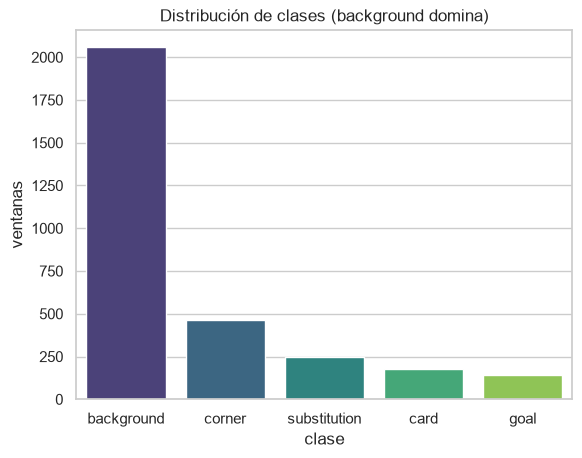

In [2]:
class_order = ["background", "corner", "substitution", "card", "goal"]
counts = manifest["label"].value_counts().reindex(class_order)
imbalance = counts.max() / counts.min()
print(counts)
print(f"\nRatio de desbalance (mayoritaria/minoritaria): {imbalance:.1f}x")
print(f"Proporción background: {counts['background'] / counts.sum():.1%}")

ax = sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette="viridis", legend=False)
ax.set(title="Distribución de clases (background domina)", xlabel="clase", ylabel="ventanas")
plt.show()

## 2. Eventos por minuto y mitad

¿Hay sesgos temporales? (ej. más sustituciones al final, más córners en ciertas franjas).

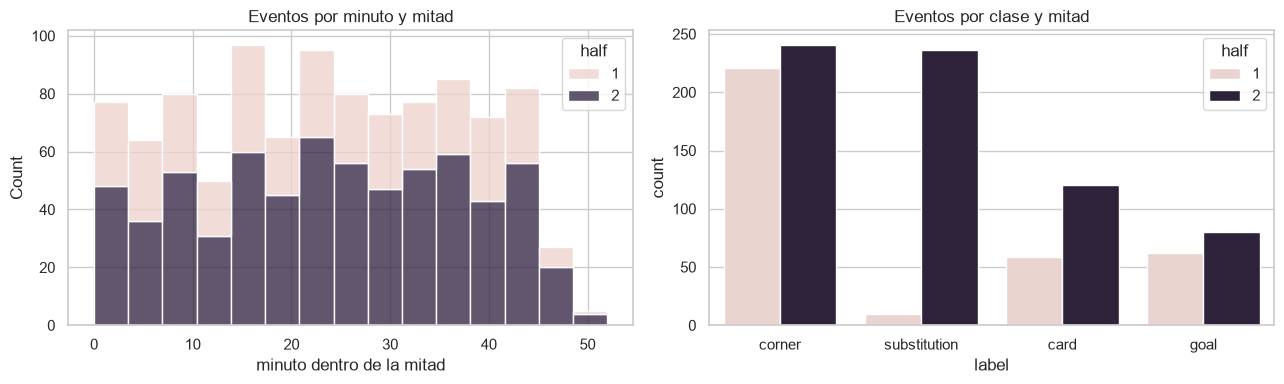

In [3]:
ev = manifest[manifest["label"] != "background"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(ev, x="minute", hue="half", multiple="stack", bins=15, ax=axes[0])
axes[0].set(title="Eventos por minuto y mitad", xlabel="minuto dentro de la mitad")
sns.countplot(ev, x="label", hue="half", order=["corner", "substitution", "card", "goal"], ax=axes[1])
axes[1].set(title="Eventos por clase y mitad")
plt.tight_layout(); plt.show()

## 3. Cobertura por split (sanity de la partición por game_id)

Los splits son por partido (invariante 1). Con pocos partidos, val/test tienen cobertura fina por clase: lo verificamos para no llevarnos sorpresas en la evaluación de Fase 2.

Ligas presentes: ['england_epl', 'europe_uefa-champions-league', 'france_ligue-1', 'germany_bundesliga', 'italy_serie-a', 'spain_laliga'] → subconjunto cross-liga (se corrigió el sesgo de tomar solo la Premier)
label  background  corner  substitution  card  goal
split                                              
test          414      96            52    35    24
train        1194     253           147   110    87
val           450     113            47    34    31


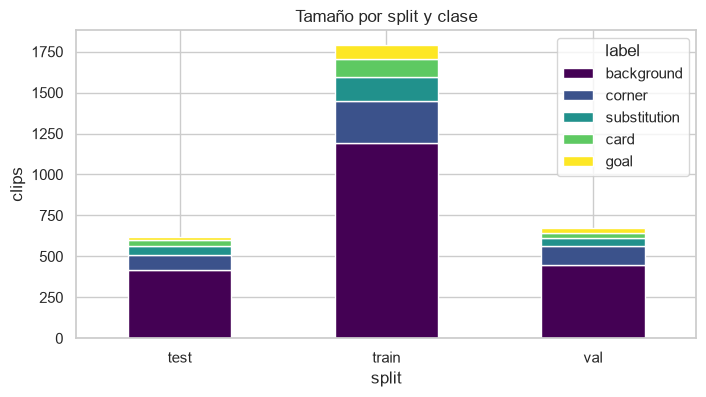

In [4]:
print("Ligas presentes:", sorted(manifest["league"].unique()),
      "→ subconjunto cross-liga (se corrigió el sesgo de tomar solo la Premier)")
pivot = manifest.pivot_table(index="split", columns="label", values="window_id",
                             aggfunc="count", fill_value=0).reindex(columns=class_order)
print(pivot)
pivot.plot(kind="bar", stacked=True, colormap="viridis", figsize=(8, 4))
plt.title("Tamaño por split y clase"); plt.ylabel("clips"); plt.xticks(rotation=0); plt.show()

## 4. Feature tabular point-in-time: `score_diff`

Distribución de la diferencia de score acumulada (home − away) calculada **solo con goles previos a t** (invariante 2).

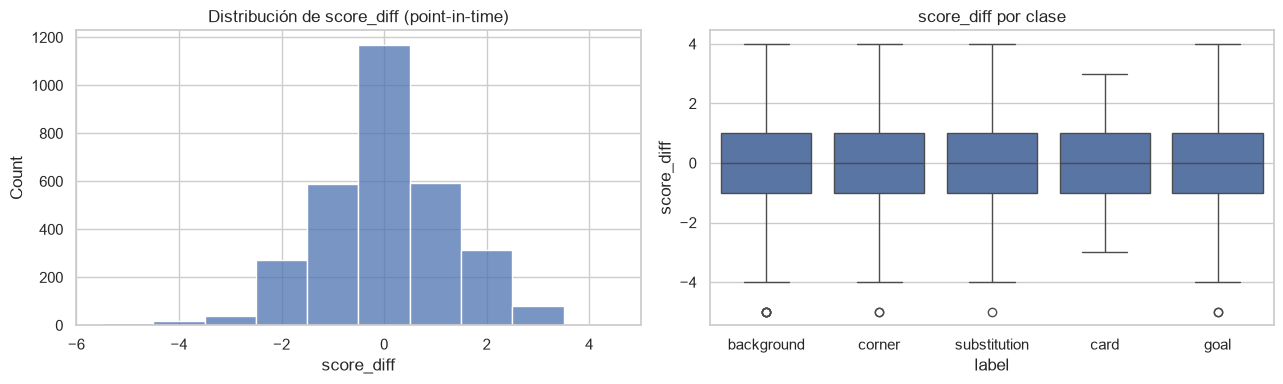

              visible  events_so_far  secs_since_last_event
label                                                      
background       0.00         102.25                  63.46
card             0.92         135.72                  17.22
corner           0.85         105.16                  25.10
goal             1.00         115.16                   4.45
substitution     0.86         159.11                  90.45


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(manifest, x="score_diff", bins=range(-4, 5), discrete=True, ax=axes[0])
axes[0].set(title="Distribución de score_diff (point-in-time)")
sns.boxplot(manifest, x="label", y="score_diff", order=class_order, ax=axes[1])
axes[1].set(title="score_diff por clase")
plt.tight_layout(); plt.show()
print(manifest.groupby("label")[["visible", "events_so_far", "secs_since_last_event"]].mean().round(2))

## Hallazgos

1. **Desbalance fuerte y deliberado.** `background` es ~2/3 de las ventanas (ratio
   2:1 por construcción, no natural). Confirma que hay que reportar
   **precision/recall/F1 por clase y PR-AUC**, nunca accuracy a secas, y usar
   `class_weight` en el entrenamiento del CNN.

2. **Clases minoritarias críticas.** `goal` y `card` son las más raras; en val/test
   quedan pocas decenas por clase → la métrica por clase es ruidosa. Se mitigó
   escalando el dataset (16 → 44 partidos), que casi duplicó las minoritarias.

3. **Señal temporal y de contexto.** La distribución de eventos por minuto/mitad y la
   feature `score_diff` (point-in-time, invariante 2) muestran estructura — útil para
   entender el problema, aunque el modelo de producción es visual-only.

4. **Diversidad de ligas.** El subconjunto cubre 6 ligas (Premier, LaLiga, Champions,
   Serie A, Bundesliga, Ligue 1): se corrigió el sesgo de tomar solo la Premier, y el
   test incluye partidos de ligas no vistas (mide generalización real).

5. **Splits por partido verificados.** La partición es por `game_id` (invariante 1);
   ninguna ventana del mismo partido cruza splits (test de regresión `test_leakage.py`).